# Experiment B2a: Univariate-on-Heterogeneous Discriminator + Homo-Low Arm

**Question.** The heterogeneity finding (Log Exps 24-26) has two live
explanations that current data cannot separate:
- **H-attention:** joint channel attention is corrupted by mixing
  dynamically incompatible channels.
- **H-signal:** low-structure channels are individually harder for
  Panda; "heterogeneous" subsets degrade because they *contain* such
  channels, not because of any cross-channel interaction.

The unification check (July 2026) showed the existing subsets confound
these: homo_matched is 7/7 high-structure channels; hetero_controlled
is 4 high + 3 low. This notebook adds the two discriminators:

1. **Univariate Panda arm** — forecasting each channel independently
   removes cross-channel attention. H-attention predicts univariate
   Panda *recovers* on the heterogeneous subset; H-signal predicts no
   recovery.
2. **Homo-low arm** — a uniformly LOW-structure subset with zero
   mixing. H-attention predicts advantage restored (nothing
   incompatible mixed); H-signal predicts advantage collapses despite
   homogeneity.

**Pre-registered criteria (fixed before running):**
- gap(mode) = PandaMAE_mode(hetero_ctrl) - PandaMAE_mode(homo_matched)
  for mode in {multi, uni}; recovery = 1 - gap_uni/gap_multi.
- recovery >= 0.5 AND paired p(uni < multi on hetero) < 0.05
  -> H-attention supported -> node-embedding branch (B2b) lives.
- recovery <= 0.2 -> H-signal supported -> B2b motivation collapses;
  heterogeneity merges into the structure/signal-family branch (B3).
- 0.2 < recovery < 0.5 -> mixed; both mechanisms contribute.
- Homo-low check: advantage(homo_low) closer to advantage(homo_matched)
  -> H-attention; closer to advantage(hetero_ctrl) or below
  -> H-signal. (Chronos MAE column serves as the difficulty control:
  it is the difficulty metric used to build the matched subsets.)
- Structure-advantage correlation (Arm 0): Spearman rho between
  per-channel Panda advantage and the Exp-30 structure statistic
  across 19 channels (rain, raining excluded as degenerate,
  registered in the log). |rho| >= 0.5 treated as supportive only —
  channels share physical drivers and are not independent samples.

**Lessons applied:** n_windows = 20 (not 8); raw predictions saved as
.npz for every arm (metric changes become re-scoring, not reruns);
per-channel MAEs recorded (feeds the correlation and any future
analysis); advantage decomposition built into the summary (who moves,
not just the difference); verbatim harness reuse (all core functions
below are byte-identical to new_experiments.ipynb — do not edit here).

**Runtime.** Core (H=96): ~600 model calls on <=7-channel inputs.
Hours on CPU, minutes-to-tens-of-minutes on a T4. Device auto-detects.
H=336 cells are optional and marked; run after the core completes.

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.linalg import svd
from scipy.stats import wilcoxon, linregress, spearmanr
from scipy.integrate import solve_ivp
from sklearn.metrics import pairwise_distances
import warnings, os
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

N_WINDOWS   = 20          # confirmatory standard (Log Section 1.2 policy)
CONTEXT_LEN = 512
PRED_LEN    = 96
DATA_DIR    = './ts_data'  # adjust if needed
OUT_NPZ_DIR = './b2a_raw_predictions'
os.makedirs(OUT_NPZ_DIR, exist_ok=True)

Device: cpu


## Model loading — verbatim from new_experiments.ipynb

In [2]:
import sys
sys.path.insert(0, './panda')

from panda.patchtst.pipeline import PatchTSTPipeline
from chronos import ChronosPipeline

panda_model = PatchTSTPipeline.from_pretrained(
    mode='predict',
    pretrain_path='GilpinLab/panda',
    device_map=device,
)

chronos_model = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map=device,
    torch_dtype=torch.bfloat16,
)

print('Models loaded.')

Models loaded.


## Core harness — VERBATIM from new_experiments.ipynb (do not edit;
any change must be mirrored there before results are compared)

In [3]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred)**2))

def instance_norm_window(x_CT):
    """x_CT: (C, T). Normalise per channel using this window only."""
    mu  = x_CT.mean(axis=1, keepdims=True)
    std = x_CT.std( axis=1, keepdims=True) + 1e-8
    return (x_CT - mu) / std, mu, std

def load_ts(path):
    """Raw (C, T) — no global normalisation."""
    df = pd.read_csv(path)
    df = df.select_dtypes(include=[np.number])
    return df.values.astype(np.float32).T  # (C, T)

def panda_forecast(context_np, horizon):
    """context_np: (C, T) normalised. Returns (C, horizon)."""
    TRAIN_H   = 128
    remaining = horizon
    ctx       = context_np.copy()
    preds     = []
    while remaining > 0:
        h         = min(TRAIN_H, remaining)
        context_t = torch.tensor(ctx.T, dtype=torch.float32)
        with torch.no_grad():
            pred = panda_model.predict(
                context_t, h,
                limit_prediction_length=False,
                sliding_context=True,
            )
        p = pred.squeeze().cpu().numpy()
        if p.ndim == 1:
            p = p[:, None]
        if p.shape[0] != context_np.shape[0]:
            p = p.T
        preds.append(p[:, :h])
        ctx       = np.concatenate([ctx[:, h:], p[:, :h]], axis=1)
        remaining -= h
    return np.concatenate(preds, axis=1)  # (C, horizon)

def chronos_forecast(context_np, horizon):
    """Batched — all channels in one call."""
    ctx = torch.tensor(context_np, dtype=torch.float32)
    with torch.no_grad():
        out = chronos_model.predict(
            ctx, prediction_length=horizon, num_samples=1
        )
    return out[:, 0, :].cpu().numpy()  # (C, horizon)

print('Verbatim harness defined.')

Verbatim harness defined.


## New forecast mode + per-channel evaluator (EXTENSIONS, documented)

`panda_forecast_univariate` slices channels and calls the verbatim
`panda_forecast` on each independently — the same one-channel-loop
pattern already used for Chronos difficulty scoring in
new_experiments.ipynb, applied to Panda. Suppresses all cross-channel
attention while keeping the temporal pipeline identical.

`evaluate_pc` reproduces the verbatim `evaluate` logic exactly
(same window starts via np.linspace, same normalisation, same paired
Wilcoxon) but additionally records the per-channel per-window MAE
matrix and saves raw predictions to .npz.

In [4]:
def panda_forecast_univariate(context_np, horizon):
    """(C, T) -> (C, H), each channel forecast independently."""
    preds = [panda_forecast(context_np[c:c+1, :], horizon)
             for c in range(context_np.shape[0])]
    return np.concatenate(preds, axis=0)

def evaluate_pc(data_CT, horizon, n_windows=N_WINDOWS, label='',
                fn_a=None, fn_b=None,
                name_a='panda', name_b='chronos',
                save_npz=True):
    """Verbatim evaluate() logic + per-channel recording + raw saving."""
    if fn_a is None: fn_a = panda_forecast
    if fn_b is None: fn_b = chronos_forecast

    C, T      = data_CT.shape
    max_start = T - CONTEXT_LEN - horizon
    if max_start <= 0:
        print(f'  [SKIP] {label}: T={T} too short')
        return None, None

    starts = np.linspace(0, max_start, n_windows, dtype=int)
    mae_a, mae_b = [], []
    pc_a = np.zeros((n_windows, C))   # per-channel MAE, model A
    pc_b = np.zeros((n_windows, C))
    raw  = {'starts': starts, 'horizon': horizon}
    preds_a, preds_b, tgts = [], [], []

    for wi, s in enumerate(starts):
        ctx_raw           = data_CT[:, s : s + CONTEXT_LEN]
        tgt_raw           = data_CT[:, s + CONTEXT_LEN : s + CONTEXT_LEN + horizon]
        ctx_norm, mu, std = instance_norm_window(ctx_raw)
        tgt_norm          = (tgt_raw - mu) / std
        pa                = fn_a(ctx_norm, horizon)
        pb                = fn_b(ctx_norm, horizon)
        mae_a.append(mae(tgt_norm, pa))
        mae_b.append(mae(tgt_norm, pb))
        pc_a[wi] = np.mean(np.abs(tgt_norm - pa), axis=1)
        pc_b[wi] = np.mean(np.abs(tgt_norm - pb), axis=1)
        preds_a.append(pa); preds_b.append(pb); tgts.append(tgt_norm)

    if save_npz:
        np.savez_compressed(
            f'{OUT_NPZ_DIR}/{label}.npz',
            preds_a=np.array(preds_a), preds_b=np.array(preds_b),
            targets=np.array(tgts), starts=starts,
            name_a=name_a, name_b=name_b,
        )

    diff = np.array(mae_b) - np.array(mae_a)
    try:
        _, pval = wilcoxon(diff, alternative='greater') \
            if np.any(diff != 0) else (0, 1.0)
    except Exception:
        pval = np.nan

    adv   = np.median(mae_b) - np.median(mae_a)
    sig   = ' *' if pval < 0.05 else (' ~' if pval < 0.10 else '')
    iqr_a = np.percentile(mae_a,75) - np.percentile(mae_a,25)
    iqr_b = np.percentile(mae_b,75) - np.percentile(mae_b,25)

    result = {
        'label': label, 'horizon': horizon,
        'name_a': name_a, 'name_b': name_b,
        f'{name_a}_mae': np.median(mae_a), f'{name_a}_iqr': iqr_a,
        f'{name_b}_mae': np.median(mae_b), f'{name_b}_iqr': iqr_b,
        'advantage_mae': adv, 'wilcoxon_p': pval,
    }
    print(f'  {label:44s} H={horizon:4d}  '
          f'{name_a}={np.median(mae_a):.4f}[±{iqr_a:.4f}]  '
          f'{name_b}={np.median(mae_b):.4f}[±{iqr_b:.4f}]  '
          f'Adv={adv:+.4f}  p={pval:.3f}{sig}')
    perch = {'pc_a': pc_a, 'pc_b': pc_b}
    return result, perch

print('Extensions defined.')

Extensions defined.


## Subsets — hardcoded from new_experiments.ipynb recorded outputs

Hardcoding the recorded indices (rather than re-running the
clustering) guarantees these are byte-identical to the subsets behind
Log Experiments 24-26, immune to library-version drift in the
clustering step. Provenance: cell-50 output of new_experiments.ipynb.

homo_low is NEW (this experiment): uniformly low-structure channels
(all Exp-30 top1/floor <= 1.49), zero mixing with the thermo family.
Its heterogeneity index is computed below with the verbatim feature
functions for the record, but the arm's purpose is the structure
test, whatever that index turns out to be.

In [5]:
WEATHER_COLS = ['p','T','Tpot','Tdew','rh','VPmax','VPact','VPdef','sh',
                'H2OC','rho','wv','max.wv','wd','rain','raining','SWDR',
                'PAR','max.PAR','Tlog','OT']

SUBSETS = {
    'homo_matched'    : [6, 8, 5, 3, 7, 2, 1],     # 7/7 thermo group
    'hetero_controlled': [16, 4, 19, 7, 12, 2, 20], # 4 thermo + 3 low
    'homo_low'        : [11, 12, 16, 17, 18, 13, 20],  # NEW: uniformly low-structure
}

# Exp-30 structure statistic (top1 / own shuffle floor), gate-validated
# instrument, native 10-min sampling. Source: tda_real_channels_v2.
STRUCT = {0:1.32, 1:1.95, 2:2.15, 3:2.03, 4:3.36, 5:1.94, 6:2.37,
          7:2.69, 8:2.42, 9:2.59, 10:1.46, 11:0.98, 12:0.72, 13:1.49,
          14:0.45, 15:0.98, 16:0.73, 17:0.59, 18:0.39, 19:1.98, 20:1.05}
DEGENERATE = [14, 15]   # rain, raining — registered exclusion

for name, idx in SUBSETS.items():
    s = [STRUCT[c] for c in idx]
    print(f'{name:18s} channels={idx}  struct: min={min(s):.2f} '
          f'median={np.median(s):.2f} max={max(s):.2f}')

homo_matched       channels=[6, 8, 5, 3, 7, 2, 1]  struct: min=1.94 median=2.15 max=2.69
hetero_controlled  channels=[16, 4, 19, 7, 12, 2, 20]  struct: min=0.72 median=1.98 max=3.36
homo_low           channels=[11, 12, 16, 17, 18, 13, 20]  struct: min=0.39 median=0.73 max=1.49


## Heterogeneity index of homo_low — verbatim feature machinery

In [6]:
from scipy.spatial.distance import pdist, squareform
from scipy.signal import periodogram

def compute_channel_features(data_CT):
    """VERBATIM from new_experiments.ipynb cell 26."""
    C, T     = data_CT.shape
    features = []
    for c in range(C):
        ts       = data_CT[c].astype(float)
        ts_norm  = (ts - ts.mean()) / (ts.std() + 1e-8)
        freqs, power = periodogram(ts_norm)
        p_norm   = power / (power.sum() + 1e-10)
        p_norm   = p_norm[p_norm > 1e-10]
        lag1_ac  = float(np.corrcoef(ts_norm[:-1], ts_norm[1:])[0, 1])
        dom_freq = float(freqs[np.argmax(power[1:]) + 1])
        features.append([
            float(ts_norm.std()),
            float(np.mean(np.abs(ts_norm))),
            lag1_ac,
            float(-np.sum(p_norm * np.log(p_norm))),
            dom_freq,
        ])
    F = np.array(features)
    F = (F - F.min(0)) / (F.max(0) - F.min(0) + 1e-8)
    return F

def intra_cluster_heterogeneity(channel_indices, dist_matrix):
    """VERBATIM from new_experiments.ipynb cell 26."""
    idx = np.array(channel_indices)
    if len(idx) < 2:
        return 0.0
    sub = dist_matrix[np.ix_(idx, idx)]
    return float(sub[np.triu_indices(len(idx), k=1)].mean())

data_weather = load_ts(f'{DATA_DIR}/weather.csv')
print(f'Weather shape: {data_weather.shape}')

features_CT = compute_channel_features(data_weather)
dist_matrix = squareform(pdist(features_CT, metric='euclidean'))
for name, idx in SUBSETS.items():
    print(f'{name:18s} heterogeneity index = '
          f'{intra_cluster_heterogeneity(idx, dist_matrix):.4f}')

Weather shape: (21, 52696)
homo_matched       heterogeneity index = 0.0857
hetero_controlled  heterogeneity index = 0.8529
homo_low           heterogeneity index = 0.9260


## Arm 0 — Full 21-channel Weather with per-channel recording
(feeds the structure-advantage correlation; n=20; H=96)

In [7]:
H_CORE = 96
all_results, perch_store = [], {}

print('Arm 0: full Weather, panda(multi) vs chronos')
r, pc = evaluate_pc(data_weather, H_CORE, label=f'arm0_full_H{H_CORE}',
                    fn_a=panda_forecast, fn_b=chronos_forecast,
                    name_a='panda', name_b='chronos')
if r:
    r['arm'] = 'arm0_full'; all_results.append(r)
    perch_store['arm0_full'] = pc

Arm 0: full Weather, panda(multi) vs chronos


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  arm0_full_H96                                H=  96  panda=0.6386[±0.1982]  chronos=0.7920[±0.1394]  Adv=+0.1534  p=0.001 *


## Arms 1-3 — three subsets x {multi vs chronos, uni vs chronos,
uni vs multi (paired)}

In [8]:
for sname, idx in SUBSETS.items():
    data_sub = data_weather[np.array(idx), :]
    print(f'\n=== Subset: {sname} ===')

    r, pc = evaluate_pc(data_sub, H_CORE, label=f'{sname}_multi_vs_chronos_H{H_CORE}',
                        fn_a=panda_forecast, fn_b=chronos_forecast,
                        name_a='panda_multi', name_b='chronos')
    if r: r['arm'] = sname; all_results.append(r); perch_store[f'{sname}_multi'] = pc

    r, pc = evaluate_pc(data_sub, H_CORE, label=f'{sname}_uni_vs_chronos_H{H_CORE}',
                        fn_a=panda_forecast_univariate, fn_b=chronos_forecast,
                        name_a='panda_uni', name_b='chronos')
    if r: r['arm'] = sname; all_results.append(r); perch_store[f'{sname}_uni'] = pc

    # Paired uni-vs-multi: the direct H-attention test.
    r, _ = evaluate_pc(data_sub, H_CORE, label=f'{sname}_uni_vs_multi_H{H_CORE}',
                       fn_a=panda_forecast_univariate, fn_b=panda_forecast,
                       name_a='panda_uni', name_b='panda_multi',
                       save_npz=False)
    if r: r['arm'] = sname; all_results.append(r)

df = pd.DataFrame(all_results)
df.to_csv('b2a_results.csv', index=False)
print('\nSaved b2a_results.csv')


=== Subset: homo_matched ===


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  homo_matched_multi_vs_chronos_H96            H=  96  panda_multi=0.5412[±0.3306]  chronos=0.8368[±0.2211]  Adv=+0.2956  p=0.001 *


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  homo_matched_uni_vs_chronos_H96              H=  96  panda_uni=0.6150[±0.1647]  chronos=0.9296[±0.2425]  Adv=+0.3146  p=0.000 *
  homo_matched_uni_vs_multi_H96                H=  96  panda_uni=0.6150[±0.1647]  panda_multi=0.5412[±0.3306]  Adv=-0.0738  p=0.763

=== Subset: hetero_controlled ===


...

  hetero_controlled_uni_vs_chronos_H96         H=  96  panda_uni=0.6212[±0.2493]  chronos=0.7630[±0.3946]  Adv=+0.1418  p=0.001 *
  hetero_controlled_uni_vs_multi_H96           H=  96  panda_uni=0.6212[±0.2493]  panda_multi=0.5636[±0.1872]  Adv=-0.0576  p=0.923

=== Subset: homo_low ===


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  homo_low_multi_vs_chronos_H96                H=  96  panda_multi=0.6101[±0.2830]  chronos=0.8689[±0.2744]  Adv=+0.2588  p=0.000 *


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  homo_low_uni_vs_chronos_H96                  H=  96  panda_uni=0.6104[±0.3394]  chronos=0.7912[±0.2835]  Adv=+0.1808  p=0.000 *
  homo_low_uni_vs_multi_H96                    H=  96  panda_uni=0.6104[±0.3394]  panda_multi=0.6101[±0.2830]  Adv=-0.0003  p=0.378

Saved b2a_results.csv


## Pre-registered verdicts

In [9]:
def get(label_sub):
    m = df[df.label.str.startswith(label_sub)]
    return m.iloc[0] if len(m) else None

hm_multi = get(f'homo_matched_multi_vs_chronos_H{H_CORE}')
hc_multi = get(f'hetero_controlled_multi_vs_chronos_H{H_CORE}')
hm_uni   = get(f'homo_matched_uni_vs_chronos_H{H_CORE}')
hc_uni   = get(f'hetero_controlled_uni_vs_chronos_H{H_CORE}')
hl_multi = get(f'homo_low_multi_vs_chronos_H{H_CORE}')
hc_pair  = get(f'hetero_controlled_uni_vs_multi_H{H_CORE}')

gap_multi = hc_multi['panda_multi_mae'] - hm_multi['panda_multi_mae']
gap_uni   = hc_uni['panda_uni_mae']     - hm_uni['panda_uni_mae']
recovery  = 1 - gap_uni / (gap_multi + 1e-12)
p_pair    = hc_pair['wilcoxon_p']

print(f'gap_multi = {gap_multi:+.4f}   gap_uni = {gap_uni:+.4f}')
print(f'RECOVERY  = {recovery:.3f}     paired p(uni<multi on hetero) = {p_pair:.4f}')
print()
if recovery >= 0.5 and p_pair < 0.05:
    print('VERDICT (uni arm): H-ATTENTION supported. Joint channel attention is')
    print('the heterogeneity bottleneck. B2b (node embeddings / graph attention)')
    print('is motivated.')
elif recovery <= 0.2:
    print('VERDICT (uni arm): H-SIGNAL supported. No recovery from removing')
    print('cross-channel attention. B2b motivation collapses; heterogeneity')
    print('merges into the structure/signal-family branch (B3).')
else:
    print('VERDICT (uni arm): MIXED / partial recovery. Both mechanisms')
    print('plausibly contribute; report the recovery fraction, no strong claim.')

adv_hm, adv_hc = hm_multi['advantage_mae'], hc_multi['advantage_mae']
adv_hl         = hl_multi['advantage_mae']
d_to_homo, d_to_het = abs(adv_hl - adv_hm), abs(adv_hl - adv_hc)
print(f'\nadvantage: homo_matched={adv_hm:+.4f}  hetero_ctrl={adv_hc:+.4f}  '
      f'homo_low={adv_hl:+.4f}')
if adv_hl <= adv_hc or d_to_het < d_to_homo:
    print('VERDICT (homo_low arm): advantage collapses WITHOUT mixing ->')
    print('supports H-SIGNAL (structure, not heterogeneity, is operative).')
else:
    print('VERDICT (homo_low arm): advantage restored on unmixed low-structure')
    print('channels -> supports H-ATTENTION (mixing is operative).')
print('(Interpret jointly with the uni-arm verdict; agreement between the two')
print('independent discriminators is the strong outcome in either direction.)')

gap_multi = +0.0224   gap_uni = +0.0062
RECOVERY  = 0.724     paired p(uni<multi on hetero) = 0.9232

VERDICT (uni arm): MIXED / partial recovery. Both mechanisms
plausibly contribute; report the recovery fraction, no strong claim.

advantage: homo_matched=+0.2956  hetero_ctrl=+0.3342  homo_low=+0.2588
VERDICT (homo_low arm): advantage collapses WITHOUT mixing ->
supports H-SIGNAL (structure, not heterogeneity, is operative).
(Interpret jointly with the uni-arm verdict; agreement between the two
independent discriminators is the strong outcome in either direction.)


## Structure-advantage correlation (Arm 0 per-channel data)

In [10]:
pc = perch_store['arm0_full']
adv_c  = pc['pc_b'].mean(0) - pc['pc_a'].mean(0)     # per-channel advantage
diff_c = pc['pc_b'].mean(0)                          # Chronos per-channel MAE = difficulty
keep   = [c for c in range(21) if c not in DEGENERATE]
sv     = np.array([STRUCT[c] for c in keep])
av     = adv_c[keep]
dv     = diff_c[keep]

rho, p = spearmanr(sv, av)
print(f'Spearman(structure, per-channel advantage): rho={rho:+.3f}  p={p:.4f}  (n=19)')

# Difficulty-controlled partial (Spearman on residuals of rank regressions)
def rank(x): return pd.Series(x).rank().values
rs, ra, rd = rank(sv), rank(av), rank(dv)
res_s = rs - linregress(rd, rs).slope * rd - linregress(rd, rs).intercept
res_a = ra - linregress(rd, ra).slope * rd - linregress(rd, ra).intercept
rho_p, p_p = spearmanr(res_s, res_a)
print(f'Difficulty-controlled partial:              rho={rho_p:+.3f}  p={p_p:.4f}')
print()
print('Pre-registered reading: |rho| >= 0.5 in the controlled version is')
print('SUPPORTIVE (not confirmatory) of the structure hypothesis; channels')
print('share physical drivers and are not independent samples.')

per_ch = pd.DataFrame({
    'channel': [WEATHER_COLS[c] for c in range(21)],
    'struct_top1_over_floor': [STRUCT[c] for c in range(21)],
    'panda_mae': pc['pc_a'].mean(0), 'chronos_mae': pc['pc_b'].mean(0),
    'advantage': adv_c,
})
per_ch.to_csv('b2a_per_channel.csv', index=False)
print('Saved b2a_per_channel.csv')

Spearman(structure, per-channel advantage): rho=+0.114  p=0.6420  (n=19)
Difficulty-controlled partial:              rho=-0.075  p=0.7589

Pre-registered reading: |rho| >= 0.5 in the controlled version is
SUPPORTIVE (not confirmatory) of the structure hypothesis; channels
share physical drivers and are not independent samples.
Saved b2a_per_channel.csv


## Visual summary

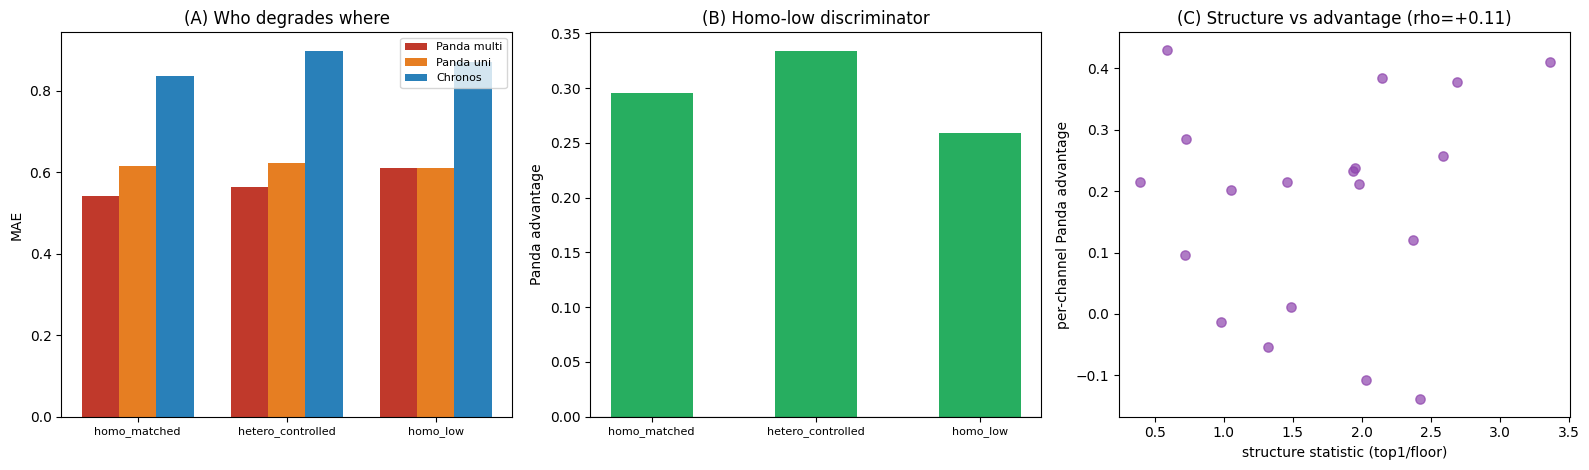

Saved b2a_summary.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
names = ['homo_matched', 'hetero_controlled', 'homo_low']
mm = [get(f'{n}_multi_vs_chronos_H{H_CORE}')[f'panda_multi_mae'] for n in names]
uu = [get(f'{n}_uni_vs_chronos_H{H_CORE}')[f'panda_uni_mae'] for n in names]
cc = [get(f'{n}_multi_vs_chronos_H{H_CORE}')['chronos_mae'] for n in names]
x = np.arange(3)
ax.bar(x-0.25, mm, 0.25, label='Panda multi', color='#c0392b')
ax.bar(x,      uu, 0.25, label='Panda uni',   color='#e67e22')
ax.bar(x+0.25, cc, 0.25, label='Chronos',     color='#2980b9')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel('MAE'); ax.legend(fontsize=8)
ax.set_title('(A) Who degrades where')

ax = axes[1]
adv = [get(f'{n}_multi_vs_chronos_H{H_CORE}')['advantage_mae'] for n in names]
ax.bar(x, adv, 0.5, color='#27ae60')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel('Panda advantage'); ax.set_title('(B) Homo-low discriminator')

ax = axes[2]
ax.scatter(sv, av, s=45, alpha=0.7, color='#8e44ad')
ax.set_xlabel('structure statistic (top1/floor)')
ax.set_ylabel('per-channel Panda advantage')
ax.set_title(f'(C) Structure vs advantage (rho={rho:+.2f})')
plt.tight_layout()
plt.savefig('b2a_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved b2a_summary.png')

## OPTIONAL — H=336 replication (run after core; ~3x Panda cost due to
window autoregression). Same arms, same criteria; agreement across
horizons strengthens whichever verdict the core produced.

In [12]:
RUN_H336 = False
if RUN_H336:
    H2 = 336
    res336 = []
    for sname, idx in SUBSETS.items():
        data_sub = data_weather[np.array(idx), :]
        for fa, fb, na, nb in [
            (panda_forecast, chronos_forecast, 'panda_multi', 'chronos'),
            (panda_forecast_univariate, chronos_forecast, 'panda_uni', 'chronos'),
            (panda_forecast_univariate, panda_forecast, 'panda_uni', 'panda_multi'),
        ]:
            r, _ = evaluate_pc(data_sub, H2, label=f'{sname}_{na}_vs_{nb}_H{H2}',
                               fn_a=fa, fn_b=fb, name_a=na, name_b=nb,
                               save_npz=(nb == 'chronos'))
            if r: r['arm'] = sname; res336.append(r)
    pd.DataFrame(res336).to_csv('b2a_results_H336.csv', index=False)
    print('Saved b2a_results_H336.csv')